# Semiconductor Equipment Reliability and Anomaly Detection: Exploratory Data Analysis

Now that we have cleaned data sets for both training and testing sets, we will use this step to explore the data. Identifying patterns, understanding distributions, and visualizing failure rates will help build intuition before modeling.

This process helps understand which sensors behave differently when wafer fails. Then, we can pinpoint which step in the manufacturing process is cauding wafer to fail and fix the root cause. 

However, before moving to EDA, I want to make sure that our selected imputation (Median - in data cleaning process) looks reasonable. This makes sure the data is ready for Exploratory Data Analysis.

My goals for this step are to:
- Verify imputation, if unreasonable then fix it
- Visualize the distribution of sensor readings
- Identiy correlations between sensors
- Visualize failure rate patters
- Run PCS to see if pass/fail clusters seperate

### Verify imputation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading cleaned data
X_train = pd.read_csv('../data/X_train_clean.csv')
X_test = pd.read_csv('../data/X_test_clean.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"y_train value counts:\n{y_train.value_counts()}")

X_train: (1253, 474)
y_train value counts:
Pass/Fail
-1    1172
 1      81
Name: count, dtype: int64


In [5]:
train_means = X_train.mean()
test_means = X_test.mean()

diff = (train_means - test_means).abs()
print(diff)

print(f"\nAverage difference between train and test sensor means: {diff.mean():.4f}")
print(f"Max difference: {diff.max():.4f}")
print(f"Sensors with large difference (>10): {(diff > 10).sum()}")

0      8.750578
1      4.533906
2      1.506696
3      9.585806
4      3.547686
         ...   
469    0.263353
470    0.000284
471    0.000719
472    0.000266
473    3.652606
Length: 474, dtype: float64

Average difference between train and test sensor means: 2.8861
Max difference: 202.8162
Sensors with large difference (>10): 24


These are interesting results. One sensor has a very high difference between the training and test means. We should look into it further more. 

There are 24 sensors that have a difference greater than 10. However, the average difference is about 2.89 which indicates that the imputation worked well, overall. 

It is important to note that the 24 sensors with high difference does not necessarily mean that the imputation failed. It could imply that those sensons may naturally have high variance, and splitting them into training and testing datasets caused the extreme values to influence the means. 

In [7]:
# Finding the sensor with the largest difference
largest_diff_sensor = diff.idxmax()

print(f"Sensor with largest difference: {largest_diff_sensor}")
print(f"Train mean: {train_means[largest_diff_sensor]}")
print(f"Test mean: {test_means[largest_diff_sensor]}")

Sensor with largest difference: 152
Train mean: 4024.2633679169994
Test mean: 4227.079617834395


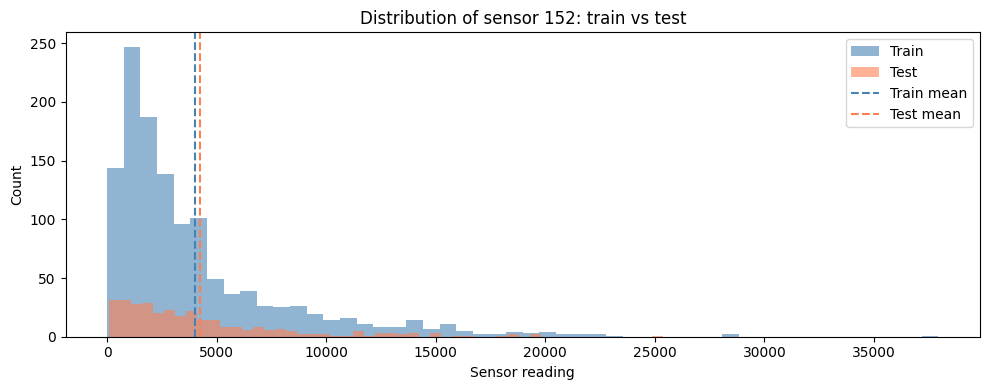

In [9]:
# Plotting its distribution for train vs test
plt.figure(figsize=(10, 4))
plt.hist(X_train[largest_diff_sensor], bins=50, alpha=0.6, label='Train', color='steelblue')
plt.hist(X_test[largest_diff_sensor], bins=50, alpha=0.6, label='Test', color='coral')
plt.axvline(train_means[largest_diff_sensor], color='steelblue', linestyle='--', label=f'Train mean')
plt.axvline(test_means[largest_diff_sensor], color='coral', linestyle='--', label=f'Test mean')
plt.legend()
plt.title(f'Distribution of sensor {largest_diff_sensor}: train vs test')
plt.xlabel('Sensor reading')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

From the plot above we see that:
- Sensor 152 is heavily right skewed. This is common in semiconductor sensor data and could be a result of flow rate or power reading that occassionally spikes.  
- The means are on the left of the distribution. Since the distribution is so skewed, even a small number of extreme values could pull mean in either direction.

Moreover, this result validates our choice of median over mean for imputation. The median would be further on the left, unaffected by the extremes. If we had used mean instead, then the fillefd missing values would have been inflated.

### Sensor Distribution: Pass vs Fail

In [12]:
train_df = X_train.copy()
train_df['label'] = y_train.values

# Picking the 24 sensors with large differences in their means (look at the cell above)
large_diff_sensors = diff[diff>10].index.tolist()
print(f"Number of sensors to investigate: {len(large_diff_sensors)}")
print(f"Sensors: {large_diff_sensors}")

Number of sensors to investigate: 24
Sensors: ['19', '20', '21', '22', '84', '133', '150', '151', '152', '153', '207', '232', '249', '250', '251', '252', '339', '353', '378', '391', '393', '397', '398', '407']


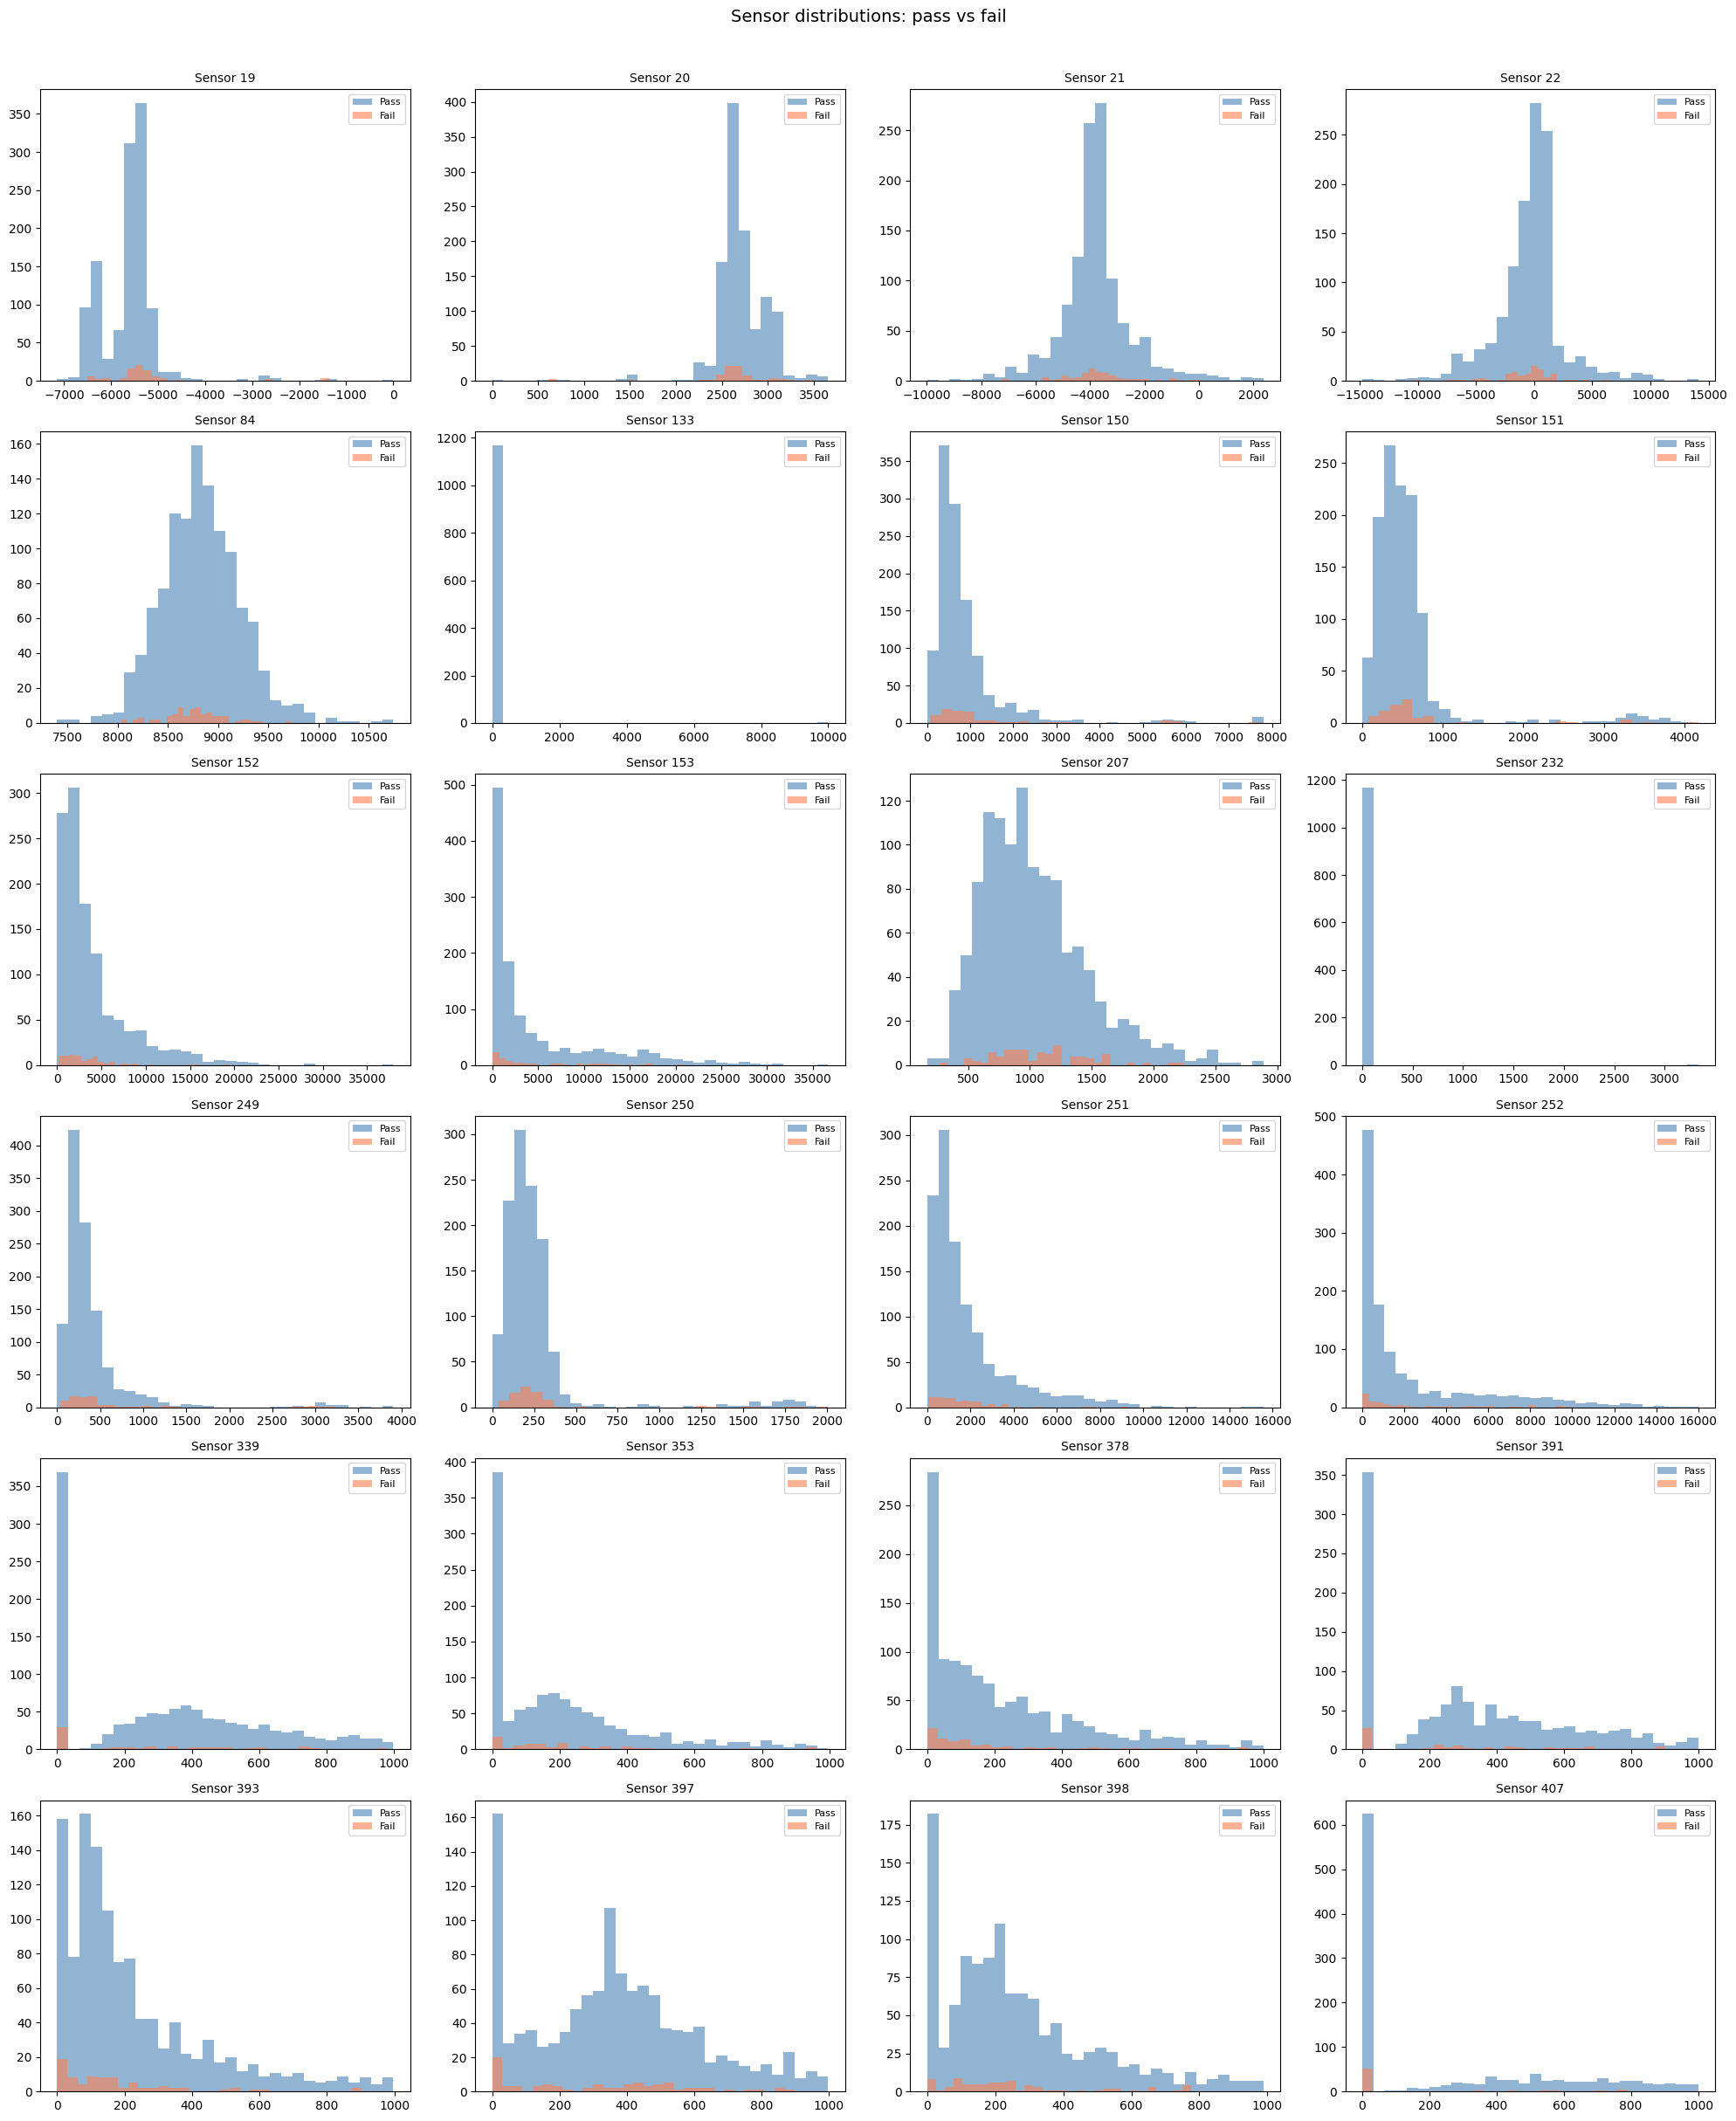

In [13]:
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()

for i, sensor in enumerate(large_diff_sensors):
    pass_vals = train_df[train_df['label'] == -1][sensor]
    fail_vals = train_df[train_df['label'] == 1][sensor]
    
    axes[i].hist(pass_vals, bins=30, alpha=0.6, label='Pass', color='steelblue')
    axes[i].hist(fail_vals, bins=30, alpha=0.6, label='Fail', color='coral')
    axes[i].set_title(f'Sensor {sensor}', fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Sensor distributions: pass vs fail', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/pass_vs_fail_distributions.png', dpi=150)
plt.show()

The histrogram plots takeaways:
- Sensor 133 and 232 have just one bar at 0, suggesting the variaance is close to 0. We could remove them since they do not provide any information about passing/failing results of wafers.
- The coral bars follow almost the same distribution as the blue bars. This is an important finding, but also a problem. These 24 sensors do not seperate from the pass or fail on their own. This shows that the failure results from a combination of sensors.

This motivates the need for a multivariate model.

### Correlation Heatmap

Since plotting a correlation matrix of all 474 sensors would be unreadable, a simpler approach would be to plot the correlation matrix of 20 sensors by variance. 

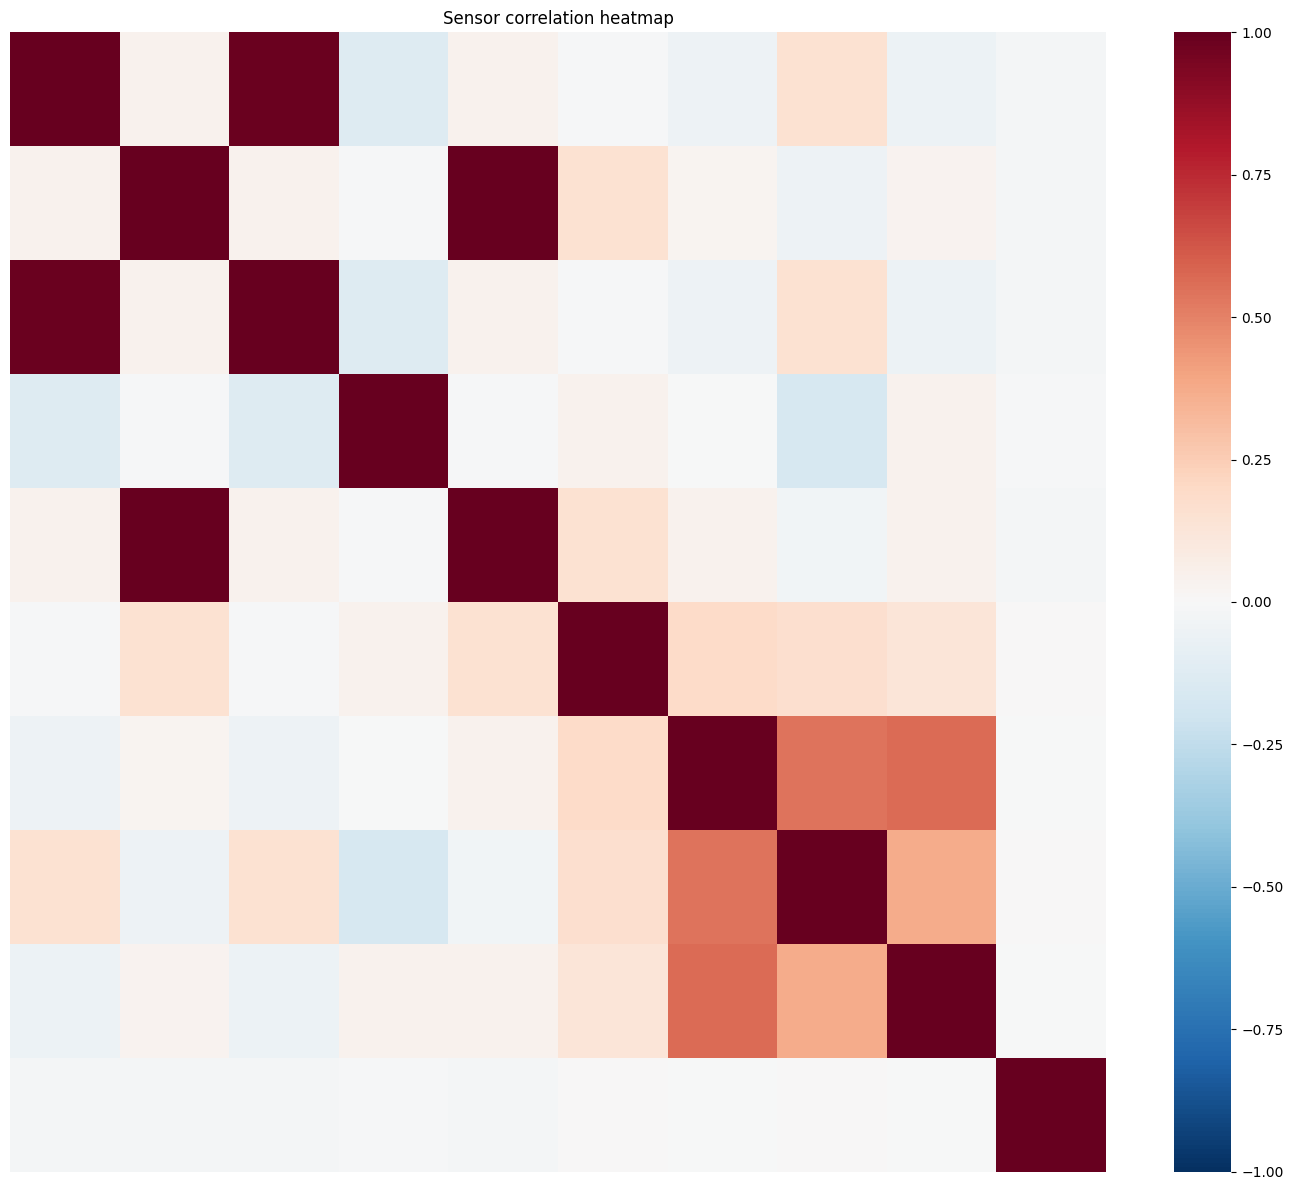

In [17]:
var_10 = X_train.var().nlargest(10).index.tolist()
corr_matrix = X_train[var_10].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0,
            xticklabels=False, yticklabels=False,
            vmin=-1, vmax=1)
plt.title('Sensor correlation heatmap')
plt.tight_layout()
plt.show()